# Week 3

# Data Loading

In [2]:
import pandas as pd

df = pd.read_csv("output.csv")

### Some common EDA

In [3]:
date_cols = ['Date of Admission', 'Discharge Date']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  datetime64[ns]
 13  Medication          54966 non-null  object    

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
row, col=df.shape
print("Row: ",row)
print("Columns: ",col)

Row:  54966
Columns:  15


In [6]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,54966.000000,54966,54966.000000,54966.000000,54966
mean,51.535185,2021-11-01 17:35:29.505512448,25546.244286,301.124404,2021-11-17 05:34:28.202161408
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13243.718641,202.000000,2020-08-13 00:00:00
50%,52.000000,2021-11-02 00:00:00,25542.749145,302.000000,2021-11-18 00:00:00
75%,68.000000,2023-02-03 00:00:00,37819.858159,401.000000,2023-02-19 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.605661,NaN,14204.924891,115.223143,NaN


In [7]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
# Filters and returns only the duplicate rows
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)


Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Doctor, Hospital, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results]
Index: []


In [10]:
unique_counts = df.nunique()
print(unique_counts)

Name                  49992
Age                      77
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1827
Doctor                40341
Hospital              39876
Insurance Provider        5
Billing Amount        50000
Room Number             400
Admission Type            3
Discharge Date         1856
Medication                5
Test Results              3
dtype: int64


# Data Visulaization and Insight Communication

## KPI

In [11]:
total_patients = len(df)
male = (df["Gender"] == "Male").sum()
female = (df["Gender"] == "Female").sum()
male_pct = male / total_patients * 100
female_pct = female / total_patients * 100
avg_billing = df["Billing Amount"].mean()
print("Total:", total_patients)
print("Male %:", round(male_pct, 2))
print("Female %:", round(female_pct, 2))
print("Average billing:", round(avg_billing, 2))


Total: 54966
Male %: 50.02
Female %: 49.98
Average billing: 25546.24


### Distribution of numerical values

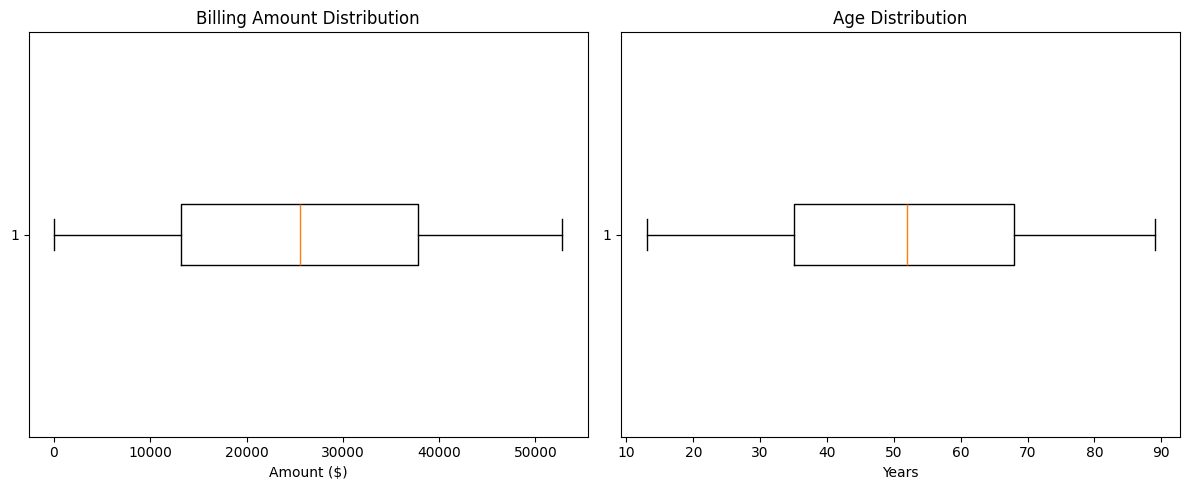

In [12]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. Plot the first figure on the left side (index 0)
axes[0].boxplot(df["Billing Amount"], vert=False)
axes[0].set_title("Billing Amount Distribution")
axes[0].set_xlabel("Amount ($)")

# 3. Plot the second figure on the right side (index 1)
axes[1].boxplot(df["Age"], vert=False)
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Years")

# 4. Clean up spacing and render
plt.tight_layout()
plt.show()

### Common Medical Conditions

In [13]:
import seaborn as sns
sns.set(style="whitegrid")

In [14]:
df["Medical Condition"].value_counts()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

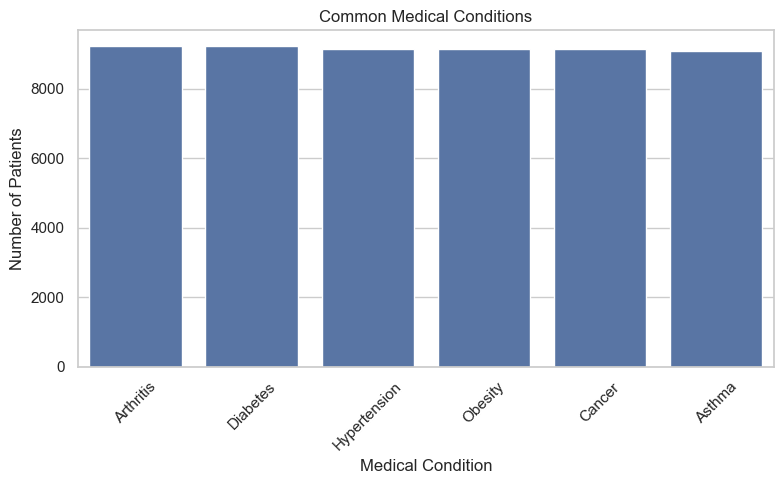

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x="Medical Condition",
              order=df["Medical Condition"].value_counts().index)
plt.title("Common Medical Conditions")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gender Distribution

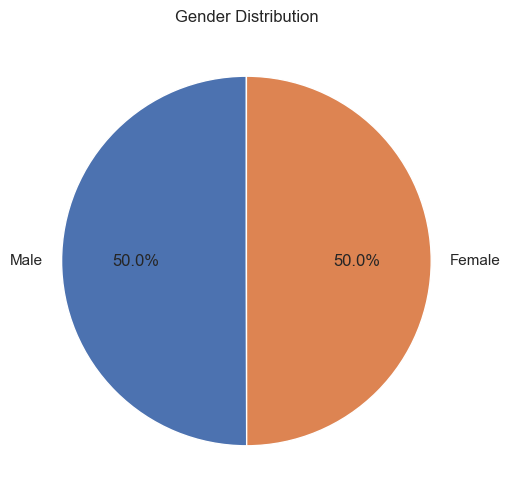

In [16]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Gender Distribution")
plt.show()

### Age group Distrubution

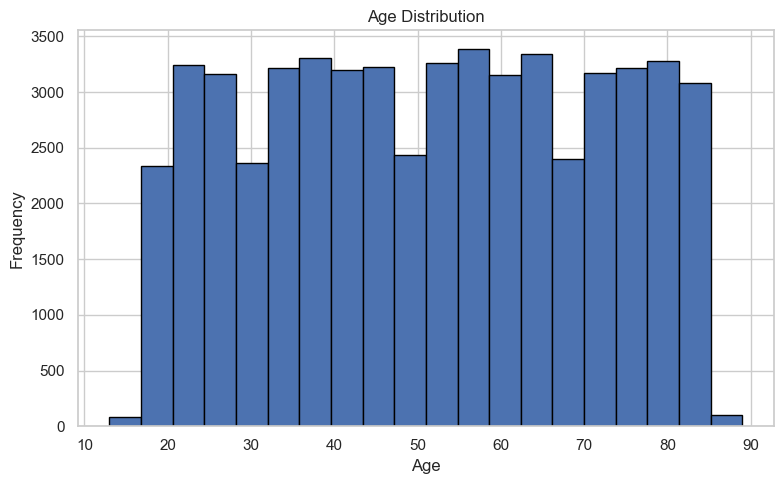

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"],
         bins=20,
         edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Billing Amount Distribution

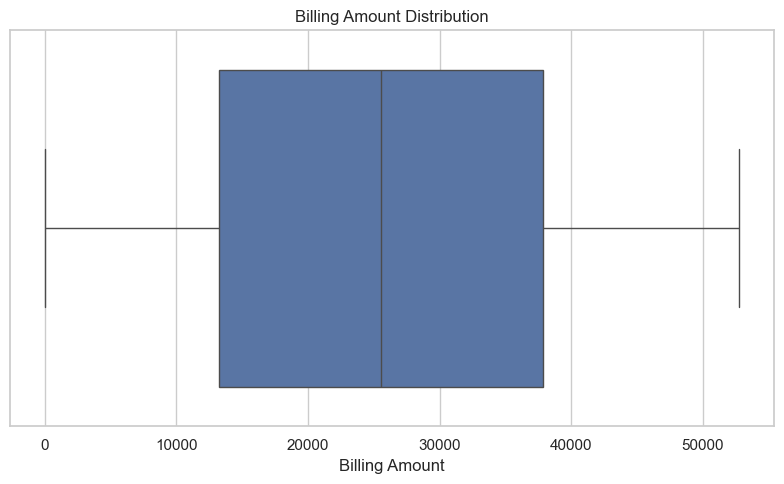

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Billing Amount"])

plt.title("Billing Amount Distribution")
plt.tight_layout()
plt.show()


### Patient admission by time

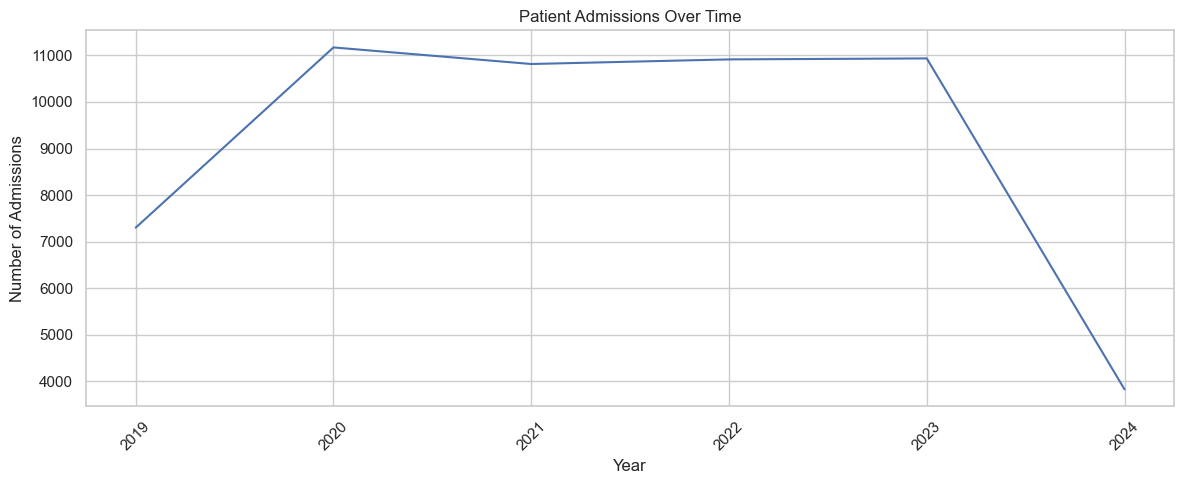

In [19]:
admissions = (
    df.groupby("Date of Admission")
      .size()
      .sort_index()
)
df['Year'] = df['Date of Admission'].dt.year
yearly_admissions = df.groupby('Year').size()

# Plot line chart
plt.figure(figsize=(12,5))
plt.plot(yearly_admissions.index,
         yearly_admissions.values)

plt.title("Patient Admissions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Admission Type Comparison

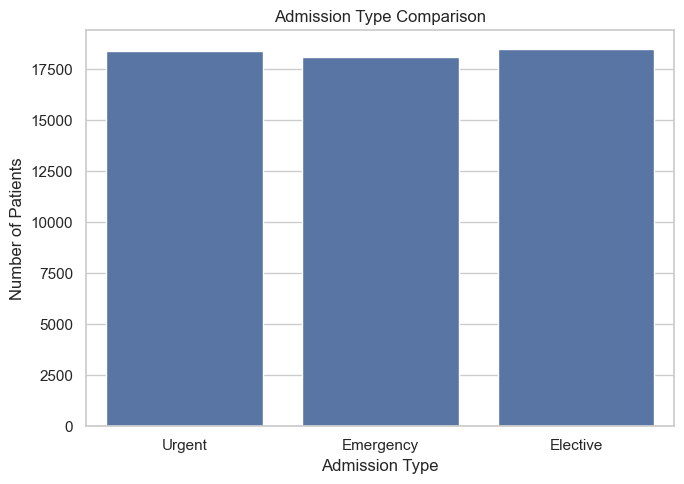

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,
              x="Admission Type")

plt.title("Admission Type Comparison")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

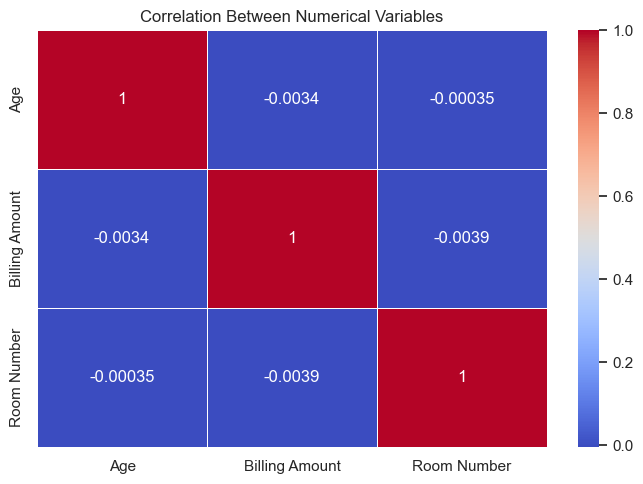

In [21]:
numeric = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(7,5))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

### Test results

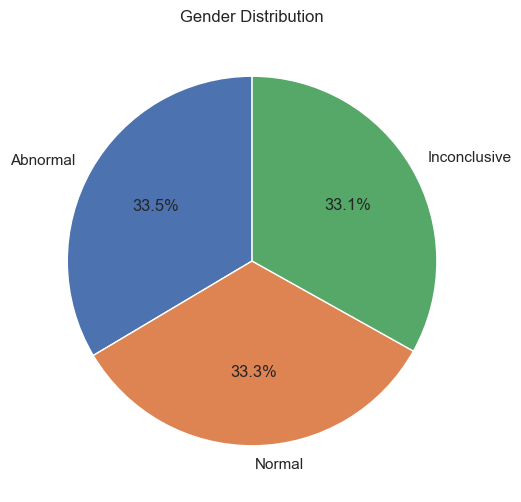

In [22]:
test_result = df["Test Results"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(test_result,
        labels=test_result.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Gender Distribution")
plt.show()

In [23]:
df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

In [24]:
df['Gender'].value_counts()

Gender
Male      27496
Female    27470
Name: count, dtype: int64

In [25]:
df['Admission Type'].value_counts()

Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

In [26]:
df['Blood Type'].value_counts()

Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64

In [27]:
df['Test Results'].value_counts()

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64

In [28]:
df[['Age','Billing Amount']].corr()

,Age,Billing Amount
Age,1.00000,-0.00341
Billing Amount,-0.00341,1.00000


# Thank You